In [1]:
# Diabetes Prediction using Machine Learning

###  Author: Ayush Kumar  
###  Date: April 2026  

## 🔍 Objective
#To build a machine learning model that predicts whether a patient has diabetes based on medical features.

## 📊 Dataset Description
#The dataset contains medical attributes such as Glucose, BMI, Age, etc., used to predict diabetes outcome.

In [2]:
##  Importing Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
##  Loading the Dataset
# Here, we load the diabetes dataset into a Pandas DataFrame for further processing.
data = pd.read_csv(r"C:\Users\ayush\OneDrive\Desktop\ML_Project\diabetes-data.csv")
data.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [4]:
##  Understanding Dataset Structure
data.info

<bound method DataFrame.info of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   5

In [5]:
## Statistical Summary
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [6]:
##  Creating a Copy of Dataset
data_copy = data.copy(deep = True)

In [7]:
##  Handling Invalid Values
data_copy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']]
data_copy[['Glucose', 'BloodPressure', 'SkinThickness',
'Insulin','BMI']].replace(0,np.NaN)

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
0,148.0,72.0,35.0,NaN,33.6
1,85.0,66.0,29.0,NaN,26.6
2,183.0,64.0,NaN,NaN,23.3
3,89.0,66.0,23.0,94.0,28.1
4,137.0,40.0,35.0,168.0,43.1
...,...,...,...,...,...
763,101.0,76.0,48.0,180.0,32.9
764,122.0,70.0,27.0,NaN,36.8
765,121.0,72.0,23.0,112.0,26.2
766,126.0,60.0,NaN,NaN,30.1


In [8]:
##  Checking Missing Values
print(data_copy.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


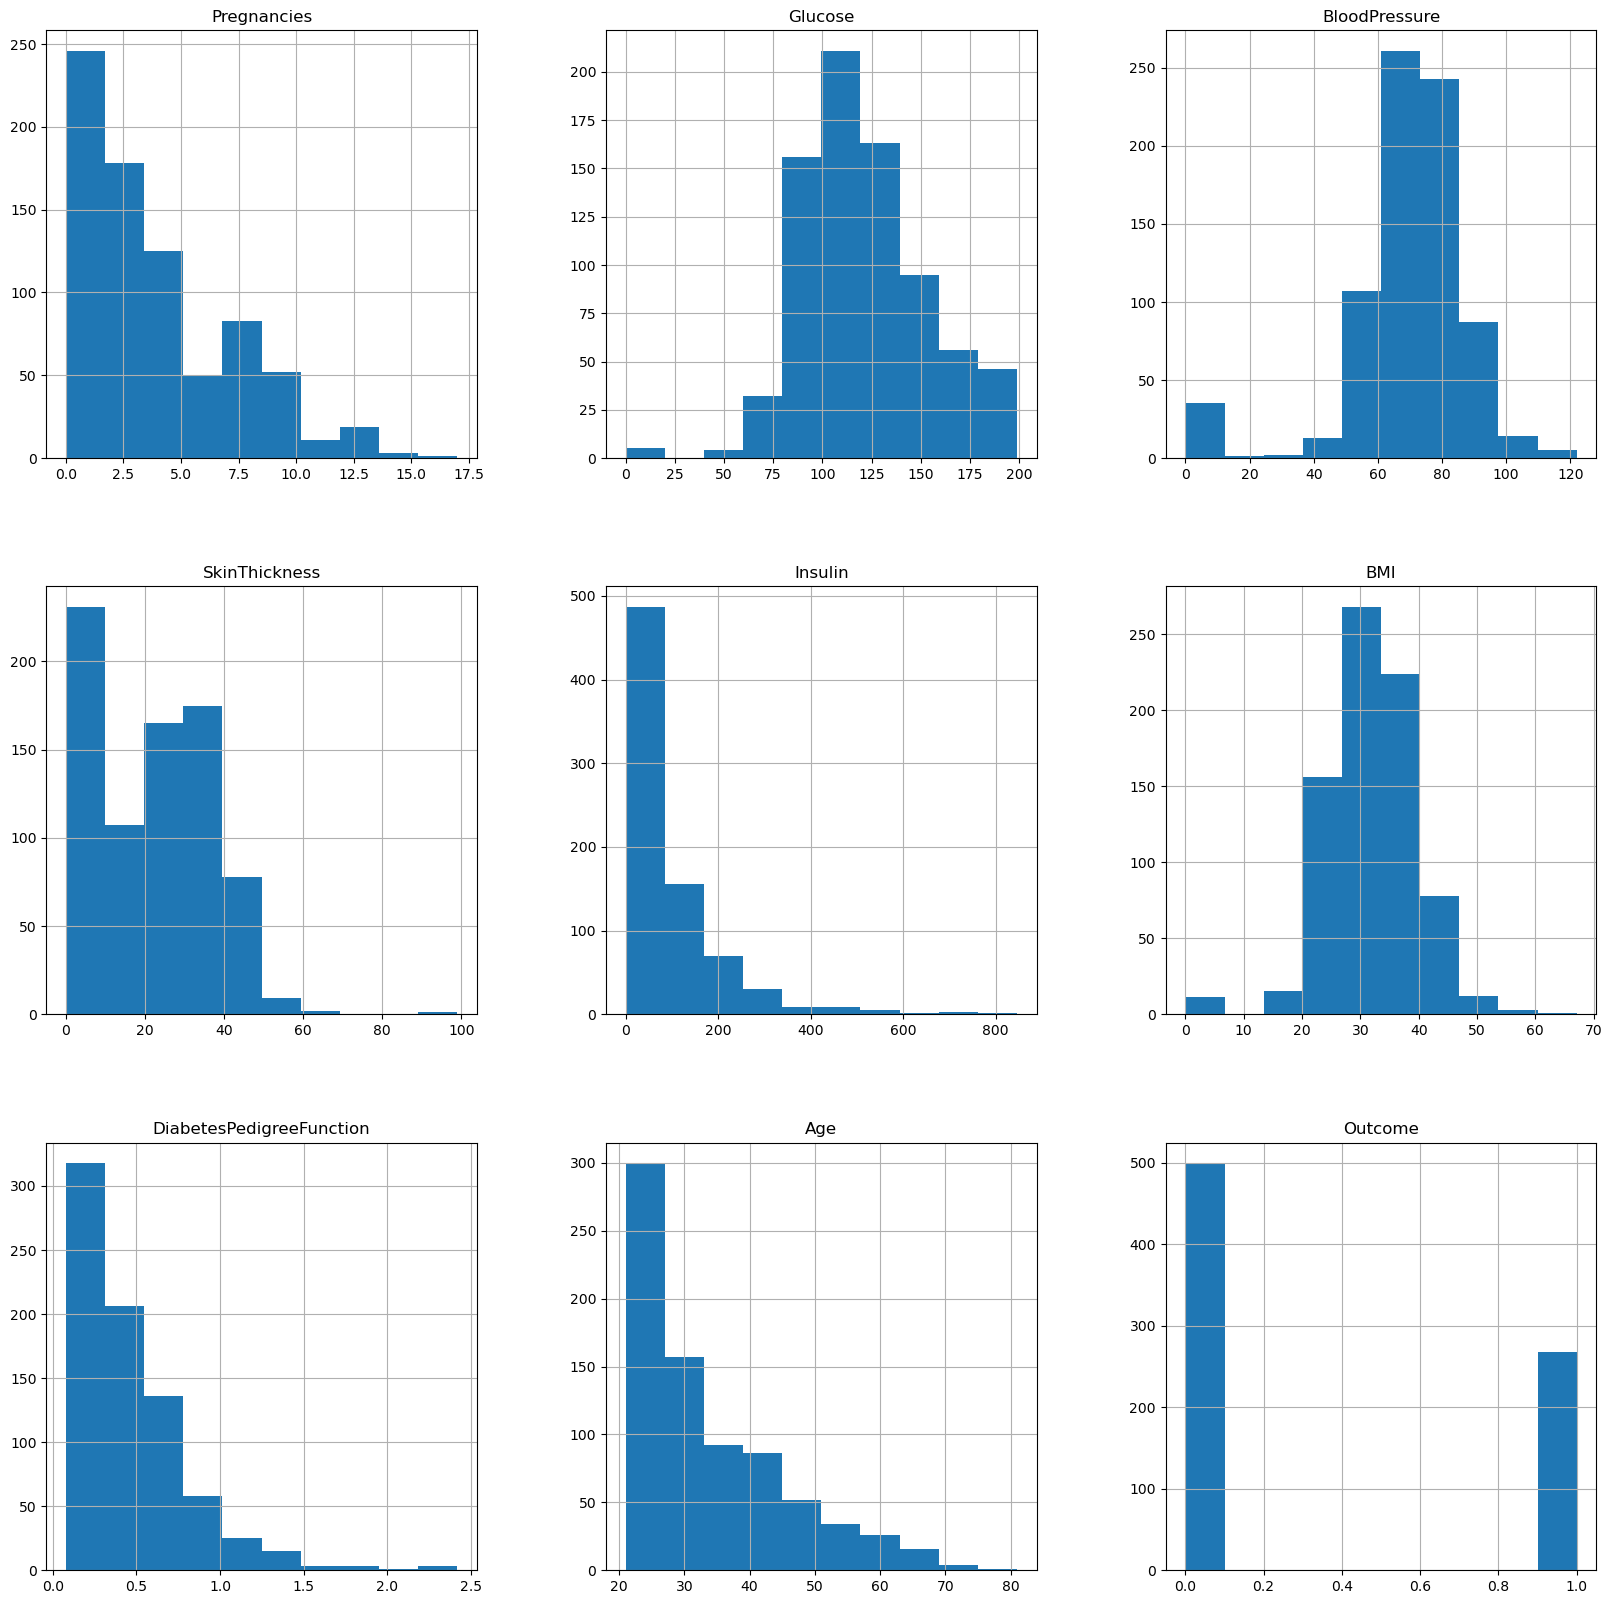

In [9]:
hplot = data.hist(figsize = (20,20))

C:\Users\ayush\AppData\Local\Temp\ipykernel_32832\2555833696.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_copy['Glucose'].fillna(data_copy['Glucose'].mean(), inplace = True)
C:\Users\ayush\AppData\Local\Temp\ipykernel_32832\2555833696.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

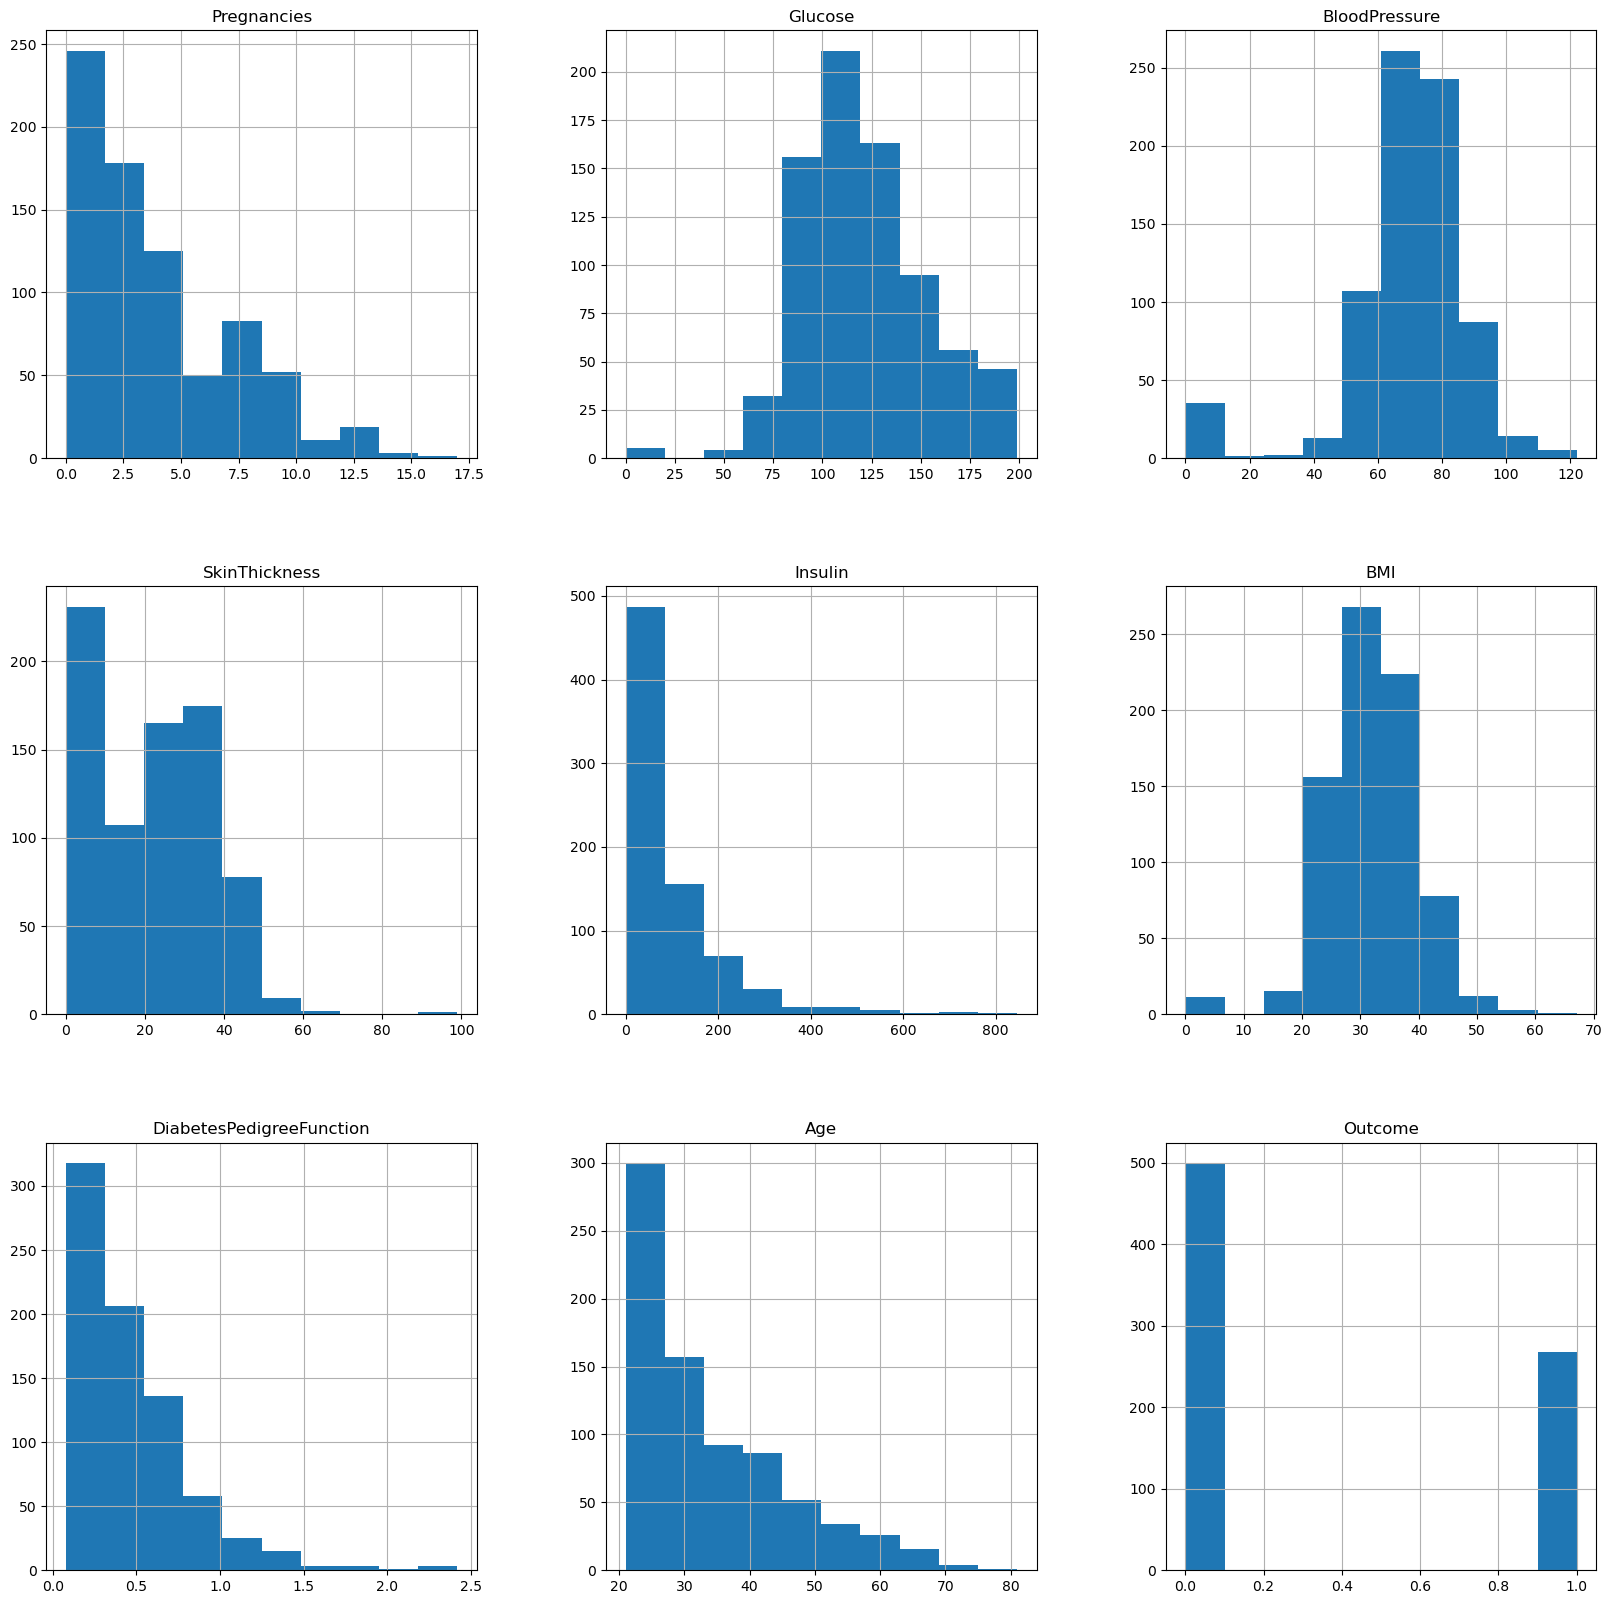

In [10]:
#  Handling Missing Data
data_copy['Glucose'].fillna(data_copy['Glucose'].mean(), inplace = True)
data_copy['BloodPressure'].fillna(data_copy['BloodPressure'].mean(), inplace = True)
data_copy['SkinThickness'].fillna(data_copy['SkinThickness'].median(), inplace = True)
data_copy['Insulin'].fillna(data_copy['Insulin'].median(), inplace = True)
data_copy['BMI'].fillna(data_copy['BMI'].median(), inplace = True)
hplot =data_copy.hist(figsize = (20,20))

In [11]:
##  Verifying Data Cleaning
data_copy.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

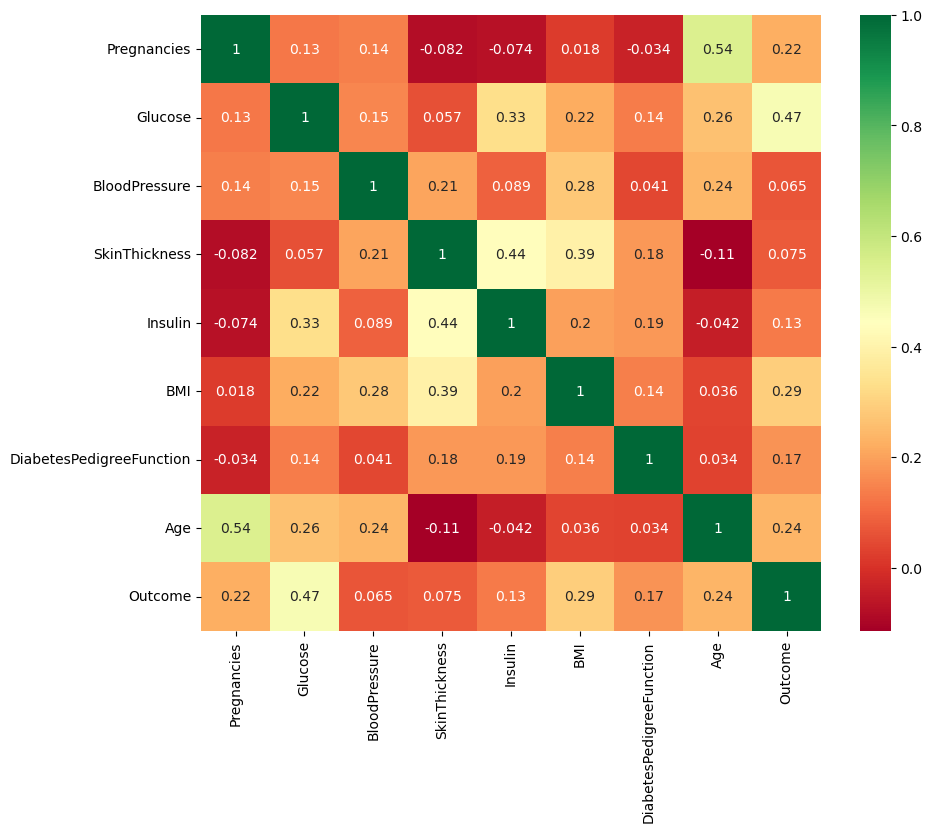

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(data_copy.corr(), annot=True, cmap='RdYlGn')
plt.show()

In [13]:
print(data.shape)

(768, 9)


In [14]:
print(data.Outcome.value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


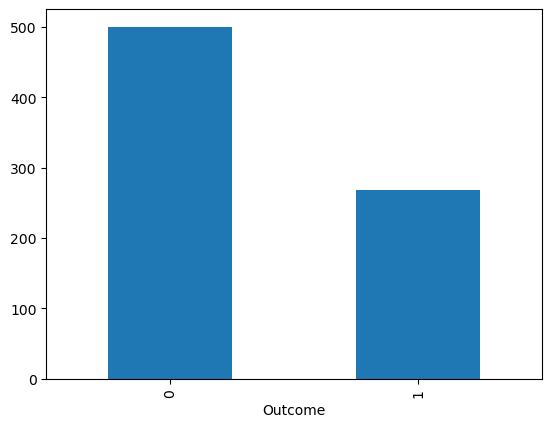

In [15]:
p=data.Outcome.value_counts().plot(kind="bar")

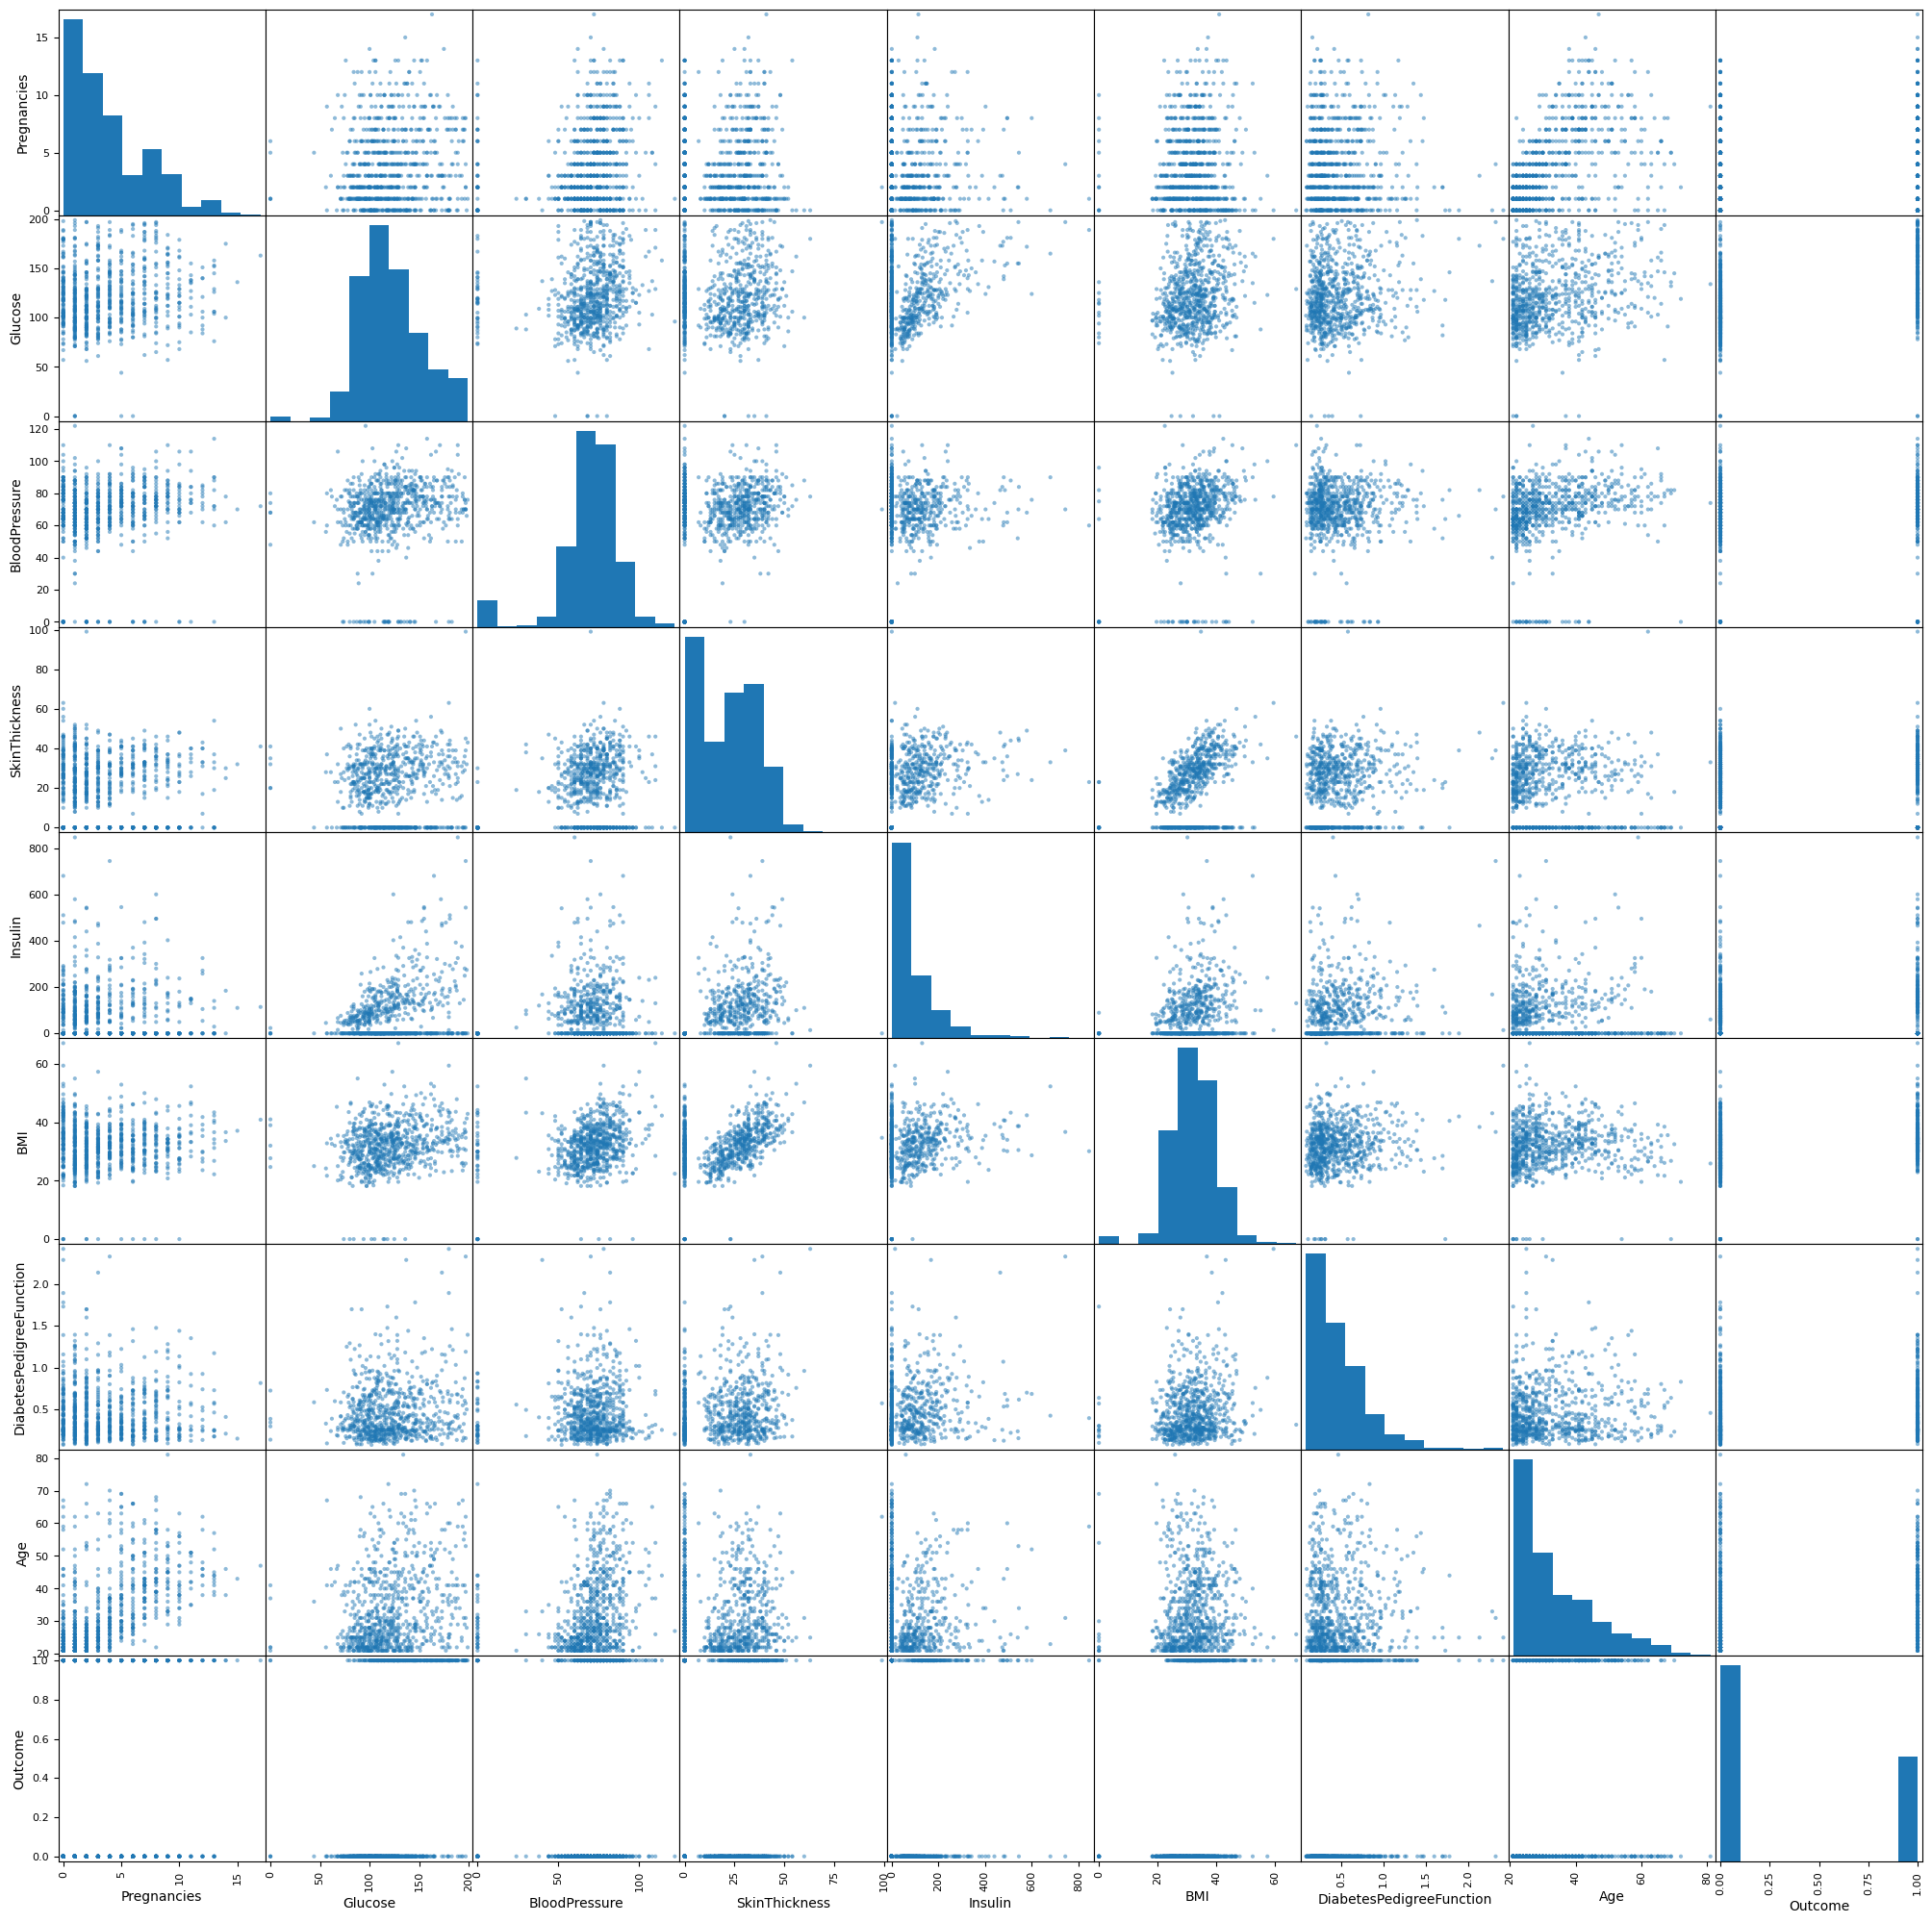

In [16]:
from pandas.plotting import scatter_matrix
p=scatter_matrix(data,figsize=(25, 25))

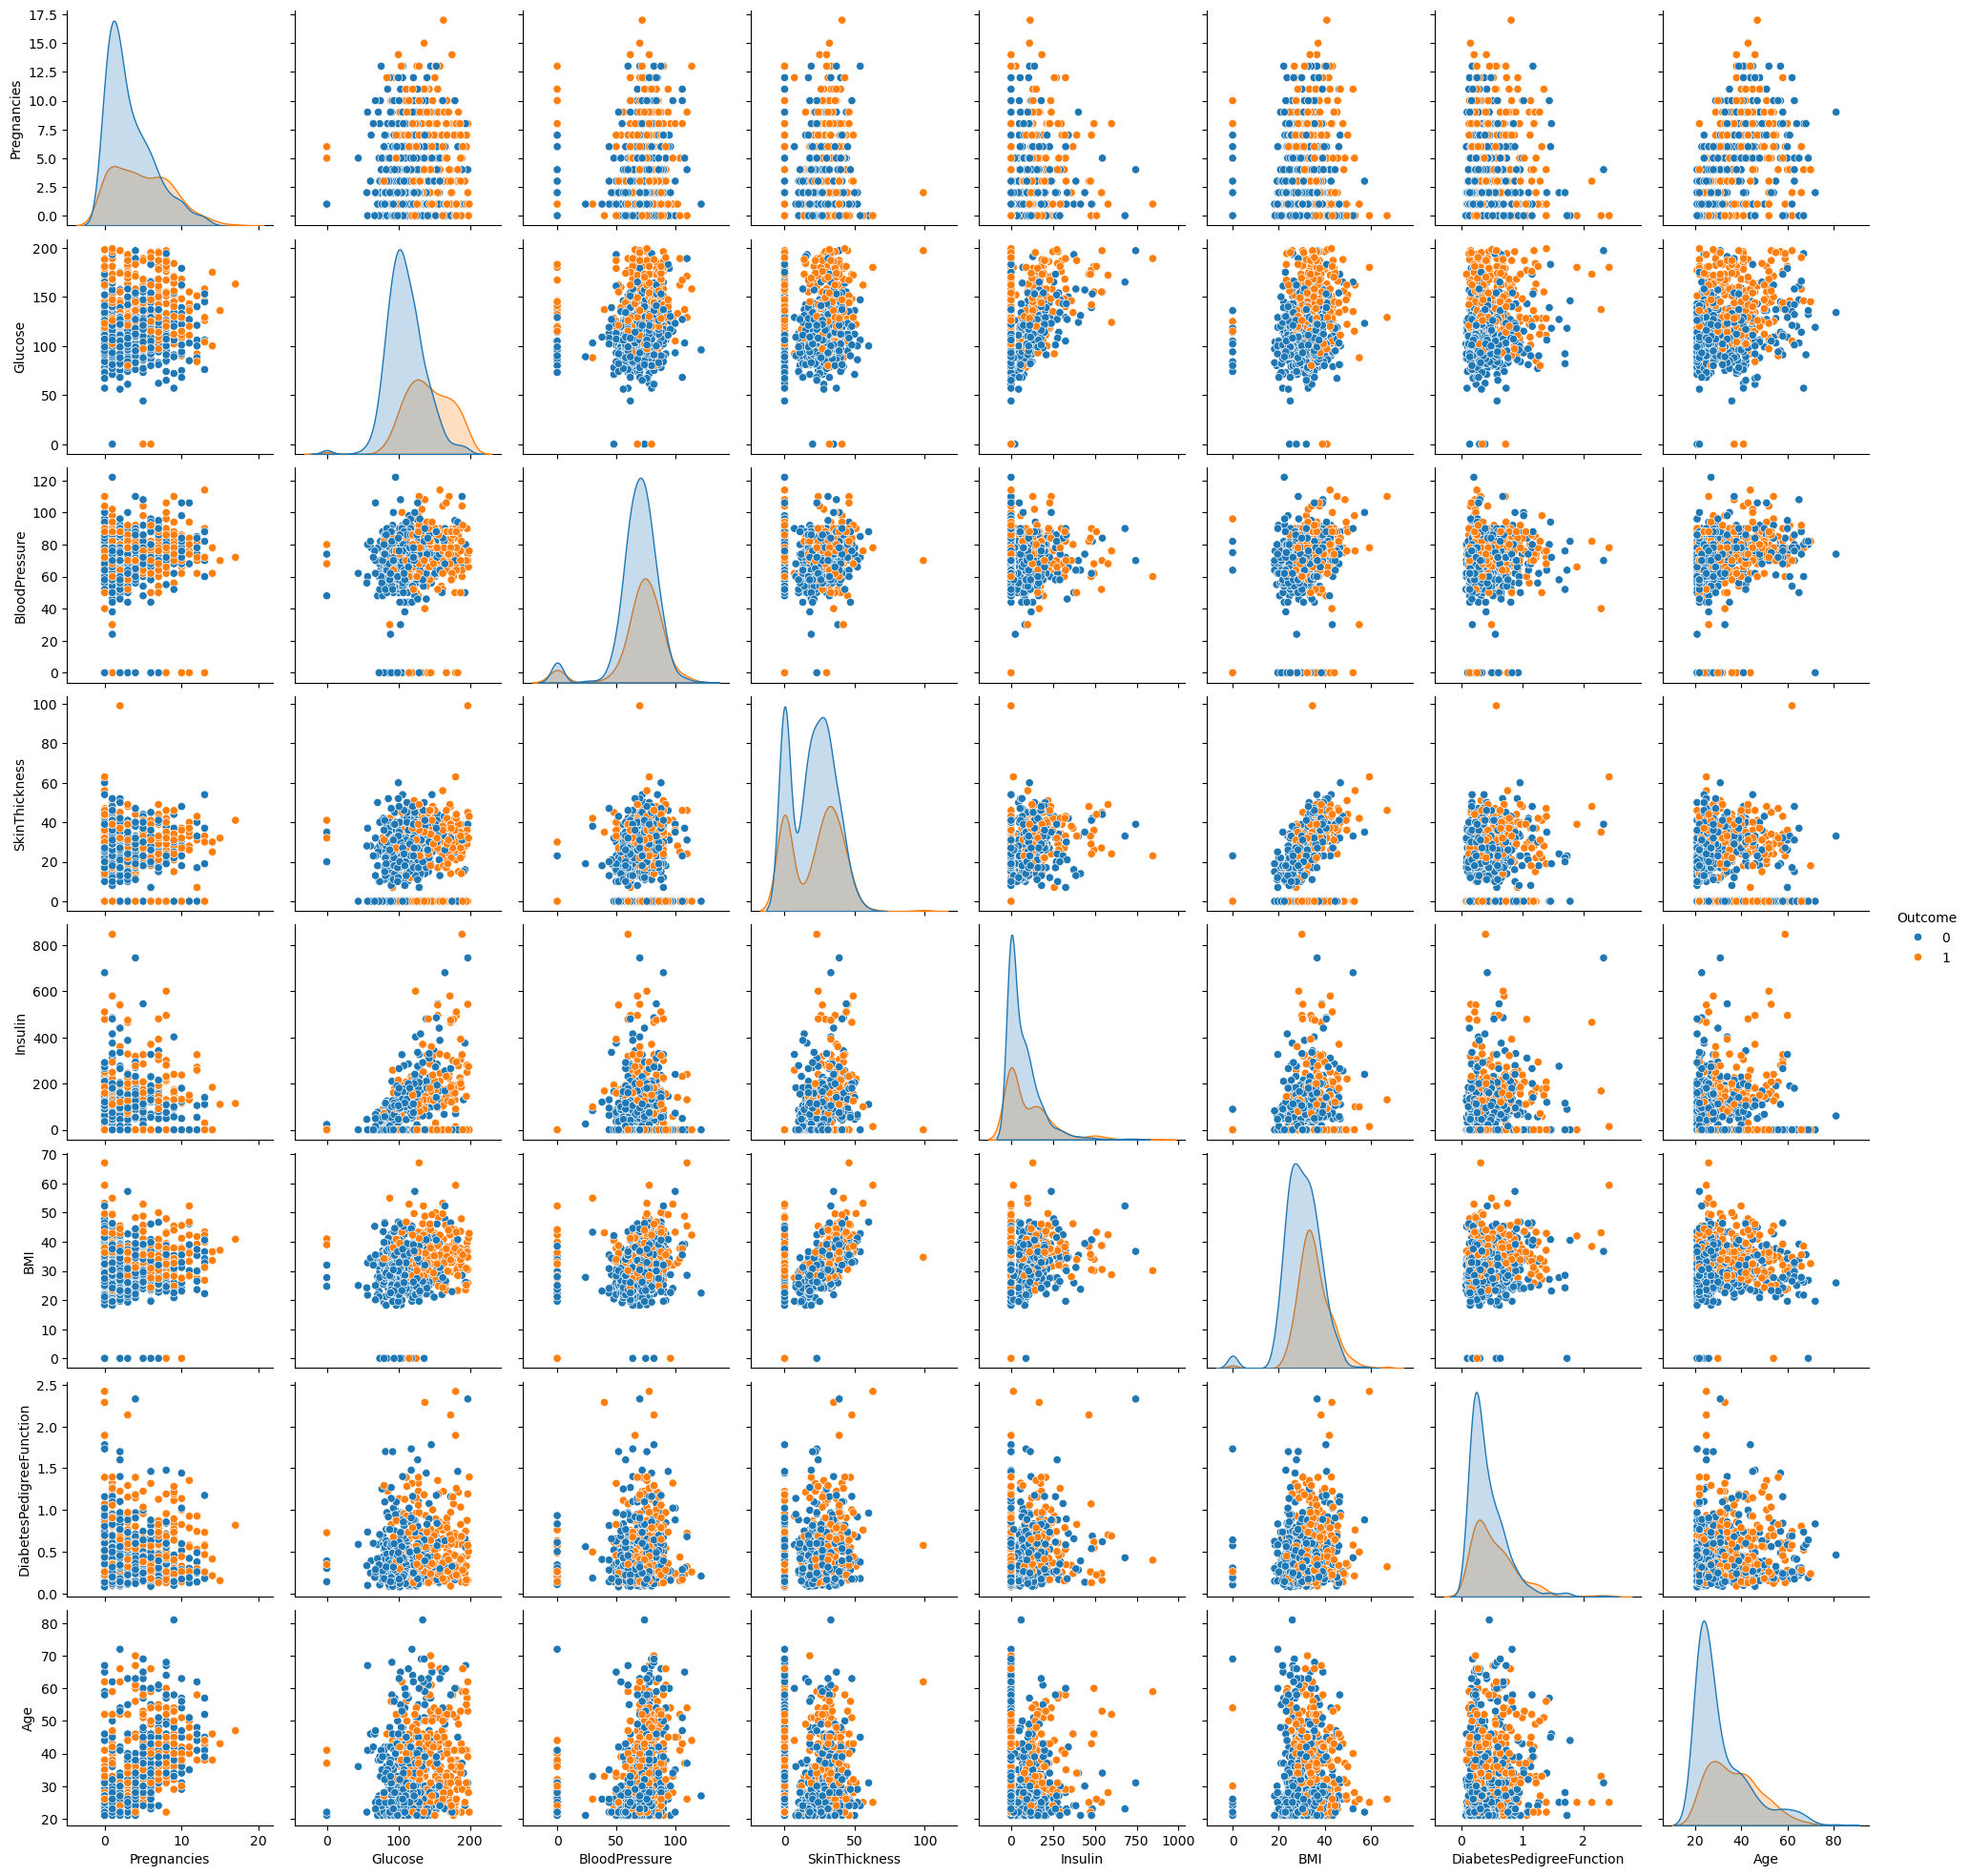

In [17]:
p=sns.pairplot(data_copy, hue ='Outcome')

In [18]:
#  Feature Selection
X = data_copy.drop("Outcome", axis=1)
y = data_copy["Outcome"]

In [19]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [21]:
# Splitting the Dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.33, random_state=42, stratify=y
)

In [22]:
# Model Training using KNN
from sklearn.neighbors import KNeighborsClassifier

training_score = []
testing_score = []

for k in range(1,15):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    training_score.append(knn.score(X_train, y_train))
    testing_score.append(knn.score(X_test, y_test))

In [23]:
# Selecting Optimal K Value
max_test_score = max(testing_score)
best_k = testing_score.index(max_test_score) + 1

print("Best K:", best_k)
print("Best Accuracy:", max_test_score)

Best K: 11
Best Accuracy: 0.7716535433070866


In [24]:

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=11)

In [25]:
# Model Evaluation
accuracy = knn.score(X_test, y_test)
print("Final Accuracy:", accuracy)

Final Accuracy: 0.7716535433070866


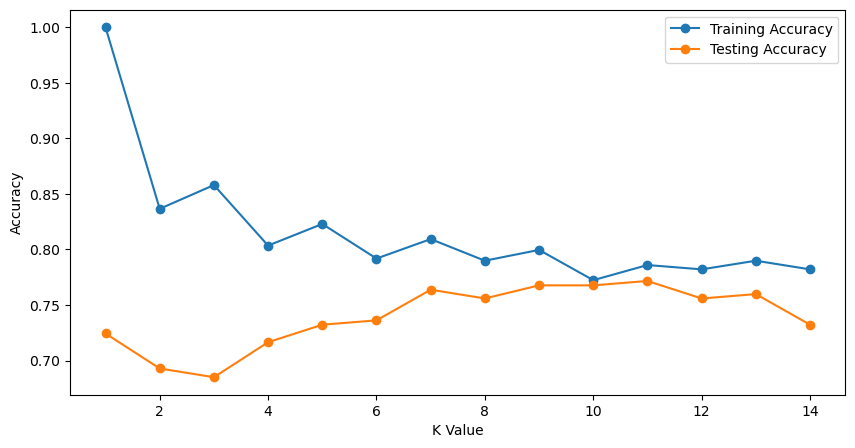

In [26]:
# Accuracy Visualization
plt.figure(figsize=(10,5))
plt.plot(range(1,15), training_score, marker='o', label="Training Accuracy")
plt.plot(range(1,15), testing_score, marker='o', label="Testing Accuracy")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [27]:
##  Conclusion
# The KNN model was successfully implemented to predict diabetes. The model achieved an accuracy of around 76–77%. This project demonstrates the complete machine learning workflow from data preprocessing to model evaluation.